In [1]:
import joblib

In [4]:
f = "data_file1.joblib.bz2"
file = joblib.load(f)

In [5]:
X_train = file['trainX']
Y_train = file["trainY"]

X_train.shape

(78646, 2000)

In [6]:
f = "data_file2.joblib.bz2"
file = joblib.load(f)

In [7]:
X_test = file['testX']
Y_test = file['testY']
max_fatures = file["max_fatures"]
bias = file["bias"]
max_fatures

8000

In [8]:
del file
del f

In [9]:
from tensorflow.keras.layers import Embedding
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from keras.layers import SpatialDropout1D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.callbacks import ModelCheckpoint
# model
embed_dim = 128
lstm_out = 100

model=Sequential()
model.add(Embedding(max_fatures, embed_dim,input_length = X_train.shape[1]))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(100)))
model.add(Dropout(0.5))
model.add(Dense(32, activation='sigmoid'))
model.add(Dense(16, activation='sigmoid'))
model.add(Dense(2,activation='softmax'))
model.compile(loss = 'categorical_crossentropy', optimizer='adam',metrics = ['accuracy'])

print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 2000, 128)         1024000   
                                                                 
 dropout (Dropout)           (None, 2000, 128)         0         
                                                                 
 bidirectional (Bidirectiona  (None, 200)              183200    
 l)                                                              
                                                                 
 dropout_1 (Dropout)         (None, 200)               0         
                                                                 
 dense (Dense)               (None, 32)                6432      
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                        

In [ ]:
batch_size = 128

# also adding weights
class_weights = {
    1: 0.54,
    0: 7.60
}

checkpoint_path = "trained_models/model.hdf5"

cp_callback = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=False,
    save_weights_only=False,
    mode='max'
)

history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=batch_size,
    verbose=1,
    validation_data=(X_test, Y_test),
    class_weight=class_weights,
    callbacks=[cp_callback]
)

Epoch 1/10


In [ ]:
import matplotlib.pyplot as plt

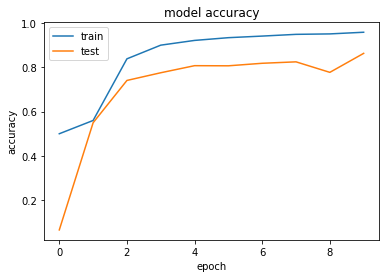

In [ ]:
# summarize history for accuracy

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

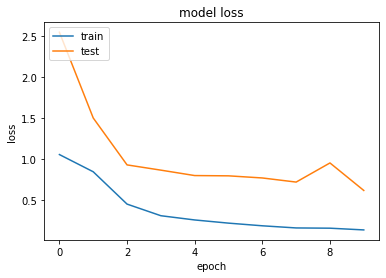

In [ ]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()